# SIIM-ISIC Mean Probability Model Blending

Extracts features, or uses cached features if already pre-made (useful if low on Kaggle time).

Use mean probability blending, evaluation on a validation set, and threshold tuning to combine model performance.


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Config
SEED = 42
VALID_FRACTION = 0.10 # validation for B7 metadata preprocessing
BLEND_VALID_FRACTION = 0.10 # validation for final blend

IMAGE_SIZE = 512
MODEL_NAME = "tf_efficientnet_b7_ns"
DROPOUT = 0.30
META_HIDDEN = 128

EVAL_BATCH_SIZE = 16
NUM_WORKERS = 0 # Set to 0 for use on Jupyter notebook on Windows
PIN_MEMORY = True
USE_AMP = True
CHANNELS_LAST = True
USE_DATAPARALLEL = False

# Keep this unchanged if you want identical predictions to the previous mean-blend run.
TTA_MODES = ("none", "hflip", "vflip", "hvflip")

OUTPUT_DIR = Path("C:/!Datasets/siim-isic-melanoma-classification/siim_meta_transformer")
CACHE_DIR = OUTPUT_DIR / "feature_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.set_float32_matmul_precision("high")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    return device


In [ ]:
# Base model configuration
# PLEASE edit checkpoint/input paths as necessary
BASE_MODELS = [
    {
        "name": "b7_joint_meta",
        "kind": "b7_meta",
        "uses_meta": True,
        "transform_backend": "albumentations",
        "checkpoint": Path("C:/Users/Omar/Downloads/resultsb7/outputs_siim_isic_b7/best_model_b7_joint_meta.pth"),
        "train_csv": Path("C:/!Datasets/siim-isic-melanoma-classification/train.csv"),
        "test_csv": Path("C:/!Datasets/siim-isic-melanoma-classification/test.csv"),
        "sample_submission": Path("C:/!Datasets/siim-isic-melanoma-classification/sample_submission.csv"),
        "image_dir": Path("C:/!Datasets/siim-isic-melanoma-classification/jpeg/train"),
        "test_image_dir": Path("C:/!Datasets/siim-isic-melanoma-classification/jpeg/test"),
        "image_size": 512,
    },
    {
        "name": "effb0_hybrid14_supcon",
        "kind": "effb0_hybrid_supcon",
        "uses_meta": False,
        "transform_backend": "torchvision",
        "checkpoint": Path("C:/Users/Omar/Downloads/effb0_transfer_kaggleHybrid_14x14_noHead_noSupCon_WS_ES_3fold_30ep_v1_fold_2_best_model.pth"),
        "train_csv": Path("C:/!Datasets/siim-isic-melanoma-classification/melanoma-dataset-512/siim_isic_512/train_resized_512.csv"),
        "test_csv": Path("C:/!Datasets/siim-isic-melanoma-classification/melanoma-dataset-512/siim_isic_512/test_resized_512.csv"),
        "sample_submission": Path("C:/!Datasets/siim-isic-melanoma-classification/sample_submission.csv"),
        "image_dir": Path("C:/!Datasets/siim-isic-melanoma-classification/melanoma-dataset-512/siim_isic_512/train"),
        "test_image_dir": Path("C:/!Datasets/siim-isic-melanoma-classification/melanoma-dataset-512/siim_isic_512/test"),
        "image_size": 224,
    },
]


In [ ]:
# Metadata preprocessing for B7's joint metadata + image processing
META_NUM_COLS = ["age_approx", "n_images", "image_size"]
META_CAT_COLS = ["sex", "anatom_site_general_challenge"]


def add_image_paths(data, image_dir):
    data = data.copy()
    data["image_name"] = data["image_name"].astype(str)
    data["patient_id"] = data["patient_id"].fillna("unknown").astype(str)
    data["image_path"] = data["image_name"].apply(lambda x: Path(image_dir) / f"{x}.jpg")
    if "target" in data.columns:
        data["target"] = data["target"].astype(int)
    return data


def add_meta_columns(data, image_dir):
    data = add_image_paths(data, image_dir)

    data["sex"] = data["sex"].fillna("unknown").astype(str).str.lower()
    data["anatom_site_general_challenge"] = (
        data["anatom_site_general_challenge"].fillna("unknown").astype(str).str.lower()
    )

    data["age_approx"] = pd.to_numeric(data["age_approx"], errors="coerce")
    data["age_missing"] = data["age_approx"].isna().astype(np.float32)
    data["n_images"] = data.groupby("patient_id")["image_name"].transform("count").astype(np.float32)
    data["image_size"] = data["image_path"].apply(
        lambda p: os.path.getsize(p) if Path(p).exists() else 0
    ).astype(np.float32)
    return data


class MetaPreprocessor:
    def __init__(self):
        self.age_median = None
        self.scaler = StandardScaler()
        self.cat_cols = None
        self.feature_cols = None

    def fit(self, train_df):
        train_df = train_df.copy()
        self.age_median = train_df["age_approx"].median()
        train_df["age_approx"] = train_df["age_approx"].fillna(self.age_median)

        cats = pd.get_dummies(train_df[META_CAT_COLS]).astype(np.float32)
        self.cat_cols = list(cats.columns)
        self.scaler.fit(train_df[META_NUM_COLS])
        self.feature_cols = META_NUM_COLS + self.cat_cols + ["age_missing"]
        return self

    def transform(self, data):
        data = data.copy()
        data["age_approx"] = data["age_approx"].fillna(self.age_median)

        num = self.scaler.transform(data[META_NUM_COLS])
        cat = pd.get_dummies(data[META_CAT_COLS]).reindex(
            columns=self.cat_cols,
            fill_value=0,
        ).astype(np.float32)

        data[self.feature_cols] = np.c_[num, cat.values, data["age_missing"].values].astype(np.float32)
        return data


def prepare_frames(spec):
    train_df = pd.read_csv(spec["train_csv"])
    test_df = pd.read_csv(spec["test_csv"])

    if not spec.get("uses_meta", True):
        return (
            add_image_paths(train_df, spec["image_dir"]).reset_index(drop=True),
            add_image_paths(test_df, spec["test_image_dir"]).reset_index(drop=True),
            [],
        )

    train_df = add_meta_columns(train_df, spec["image_dir"])
    test_df = add_meta_columns(test_df, spec["test_image_dir"])

    # Recreate the B7 notebook's patient-level fit split
    patient_targets = train_df.groupby("patient_id")["target"].max().reset_index()
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=VALID_FRACTION, random_state=SEED)
    train_idx, _ = next(splitter.split(patient_targets["patient_id"], patient_targets["target"]))
    fit_patients = set(patient_targets.iloc[train_idx]["patient_id"])
    fit_df = train_df[train_df["patient_id"].isin(fit_patients)].reset_index(drop=True)

    prep = MetaPreprocessor().fit(fit_df)
    return prep.transform(train_df).reset_index(drop=True), prep.transform(test_df).reset_index(drop=True), prep.feature_cols


In [ ]:
# Dataset and transforms
class MelanomaDataset(Dataset):
    def __init__(self, df, feature_cols=None, transform=None, is_test=False, transform_backend="albumentations"):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols or []
        self.transform = transform
        self.is_test = is_test or "target" not in df.columns
        self.transform_backend = transform_backend

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform_backend == "albumentations":
            image = self.transform(image=np.array(image))["image"]
        elif self.transform_backend == "torchvision":
            image = self.transform(image)
        else:
            raise ValueError(f"Unknown transform backend: {self.transform_backend}")

        item = {
            "image": image,
            "image_name": row["image_name"],
            "patient_id": row["patient_id"],
        }

        if self.feature_cols:
            item["meta"] = torch.tensor(row[self.feature_cols].values.astype(float), dtype=torch.float32)
        if not self.is_test and "target" in row:
            item["target"] = torch.tensor(row["target"], dtype=torch.float32)
        return item


def collate_batch(batch):
    out = {
        "image": torch.stack([x["image"] for x in batch]),
        "image_name": [x["image_name"] for x in batch],
        "patient_id": [x["patient_id"] for x in batch],
    }
    if "meta" in batch[0]:
        out["meta"] = torch.stack([x["meta"] for x in batch])
    if "target" in batch[0]:
        out["target"] = torch.stack([x["target"] for x in batch])
    return out


# Support transformations used to train both models
def make_albu_transform(image_size):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def make_torchvision_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def make_transform(spec):
    if spec.get("transform_backend") == "torchvision":
        return make_torchvision_transform(spec["image_size"])
    return make_albu_transform(spec.get("image_size", IMAGE_SIZE))


def tta(images, mode):
    if mode == "none":
        return images
    if mode == "hflip":
        return images.flip(3)
    if mode == "vflip":
        return images.flip(2)
    if mode == "hvflip":
        return images.flip(2).flip(3)
    raise ValueError(f"Unknown TTA mode: {mode}")


In [6]:
# Base models
class PlainB7Meta(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()
        self.backbone = timm.create_model(MODEL_NAME, pretrained=False, num_classes=0, global_pool="avg")
        img_dim = self.backbone.num_features

        self.meta_branch = nn.Sequential(
            nn.Linear(meta_dim, META_HIDDEN),
            nn.BatchNorm1d(META_HIDDEN),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(META_HIDDEN, META_HIDDEN),
            nn.BatchNorm1d(META_HIDDEN),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Linear(img_dim + META_HIDDEN, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(256, 1),
        )

    def forward(self, image, meta):
        img = self.backbone(image)
        meta = self.meta_branch(meta)
        return self.head(torch.cat([img, meta], dim=1)).squeeze(1)


class HybridTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.10, attn_dropout=0.10):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=attn_dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        norm = self.norm1(src)
        attn, _ = self.self_attn(
            norm,
            norm,
            norm,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
            is_causal=is_causal,
        )
        src = src + self.dropout1(attn)
        ff = self.linear2(self.dropout(F.gelu(self.linear1(self.norm2(src)))))
        return src + self.dropout2(ff)


class EffB0HybridSupCon(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn_model = models.efficientnet_b0(weights=None)
        in_features = self.cnn_model.classifier[1].in_features
        self.cnn_model.classifier[1] = nn.Linear(in_features, 1)

        embed_dim = 384
        self.feature_layer_index = 5
        self.feature_channels = 112
        self.feature_grid_size = 14
        self.token_projection = nn.Conv2d(112, embed_dim, kernel_size=1)
        self.pos_embed = nn.Parameter(torch.zeros(1, 14 * 14, embed_dim))
        self.pos_drop = nn.Dropout(0.20)

        layer = HybridTransformerEncoderLayer(
            d_model=embed_dim,
            nhead=6,
            dim_feedforward=int(embed_dim * 4.0),
            dropout=0.20,
            attn_dropout=0.15,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=4)
        self.transformer_norm = nn.LayerNorm(embed_dim)
        self.transformer_head = nn.Linear(embed_dim, 1)

        # Kept so the checkpoint loads exactly, even though the blend only needs probabilities.
        self.supcon_cnn_norm = nn.LayerNorm(1280)
        self.supcon_cnn_projection = nn.Linear(1280, 384)
        self.supcon_vit_norm = nn.LayerNorm(embed_dim)
        self.supcon_projection_head = nn.Sequential(
            nn.LayerNorm(384 + embed_dim),
            nn.Linear(384 + embed_dim, 384),
            nn.GELU(),
            nn.Linear(384, 128),
        )
        self.gate_logit = nn.Parameter(torch.tensor(-1.5))

    def extract_features(self, x):
        transformer_features = None
        features = x
        for i, layer in enumerate(self.cnn_model.features):
            features = layer(features)
            if i == self.feature_layer_index:
                transformer_features = features
        if transformer_features is None:
            raise RuntimeError("EfficientNet-B0 transformer feature layer was not reached.")
        return features, transformer_features

    def forward(self, image):
        cnn_features, transformer_features = self.extract_features(image)
        pooled = self.cnn_model.avgpool(cnn_features).flatten(1)
        cnn_logit = self.cnn_model.classifier(pooled).squeeze(1)

        tokens = self.token_projection(transformer_features).flatten(2).transpose(1, 2)
        tokens = self.pos_drop(tokens + self.pos_embed)
        tokens = self.transformer(tokens)
        transformer_embed = self.transformer_norm(tokens.mean(dim=1))
        transformer_logit = self.transformer_head(transformer_embed).squeeze(1)

        return cnn_logit + torch.sigmoid(self.gate_logit) * transformer_logit


In [ ]:
# Checkpoint loading
def load_torch(path):
    # TRY to load checkpoints in a safe manner
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        return torch.load(path, map_location="cpu", weights_only=False)


def clean_state_dict(state):
    if isinstance(state, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if key in state and isinstance(state[key], dict):
                state = state[key]
                break

    return {
        k[7:] if k.startswith("module.") else k: v
        for k, v in state.items()
    }


def build_model(spec, meta_dim):
    if spec["kind"] == "b7_meta":
        model = PlainB7Meta(meta_dim=meta_dim)
    elif spec["kind"] == "effb0_hybrid_supcon":
        model = EffB0HybridSupCon()
    else:
        raise ValueError(f"Unknown model kind: {spec['kind']}")

    state = clean_state_dict(load_torch(spec["checkpoint"]))
    model.load_state_dict(state, strict=True)
    return model


In [ ]:
# Prediction cache extraction
@torch.no_grad()
def extract_predictions(spec, split="train", force=False):
    cache_path = CACHE_DIR / f"{spec['name']}_{split}_features.npz"
    if cache_path.exists() and not force:
        print(f"Using cached predictions: {cache_path}")
        return cache_path

    device = get_device()
    train_df, test_df, feature_cols = prepare_frames(spec)
    df = train_df if split == "train" else test_df
    is_test = split != "train"

    dataset = MelanomaDataset(
        df,
        feature_cols=feature_cols,
        transform=make_transform(spec),
        is_test=is_test,
        transform_backend=spec.get("transform_backend", "albumentations"),
    )
    loader = DataLoader(
        dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY and device.type == "cuda",
        collate_fn=collate_batch,
        persistent_workers=NUM_WORKERS > 0,
    )

    model = build_model(spec, meta_dim=len(feature_cols)).to(device)
    if CHANNELS_LAST and device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    if USE_DATAPARALLEL and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.eval()

    names, patients, targets = [], [], []
    logits_all, probs_all = [], []
    uses_meta = spec.get("uses_meta", True)

    for batch in tqdm(loader, desc=f"Predict {spec['name']} {split}"):
        images = batch["image"].to(device, non_blocking=True)
        if CHANNELS_LAST and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)
        metas = batch.get("meta")
        if metas is not None:
            metas = metas.to(device, non_blocking=True)

        logit_sum = None
        prob_sum = None

        # Apply augmentations
        for mode in TTA_MODES:
            aug = tta(images, mode)
            with autocast(device.type, enabled=USE_AMP and device.type == "cuda"):
                logits = model(aug, metas) if uses_meta else model(aug)
            logits = logits.float()
            probs = torch.sigmoid(logits)
            logit_sum = logits if logit_sum is None else logit_sum + logits
            prob_sum = probs if prob_sum is None else prob_sum + probs

        logits_all.append((logit_sum / len(TTA_MODES)).cpu().numpy().astype(np.float32))
        probs_all.append((prob_sum / len(TTA_MODES)).cpu().numpy().astype(np.float32))
        names.extend(batch["image_name"])
        patients.extend(batch["patient_id"])
        if "target" in batch:
            targets.append(batch["target"].numpy().astype(np.float32))

    targets = np.concatenate(targets, axis=0) if targets else np.full(len(names), np.nan, dtype=np.float32)
    np.savez_compressed(
        cache_path,
        logits=np.concatenate(logits_all, axis=0),
        probs=np.concatenate(probs_all, axis=0),
        image_name=np.array(names),
        patient_id=np.array(patients),
        target=targets,
    )
    print(f"Saved predictions: {cache_path}")
    return cache_path


def load_prediction_cache(path):
    data = np.load(path, allow_pickle=True)
    return {
        "probs": data["probs"].astype(np.float32),
        "logits": data["logits"].astype(np.float32),
        "image_name": data["image_name"].astype(str),
        "patient_id": data["patient_id"].astype(str),
        "target": data["target"].astype(np.float32),
    }


def run_prediction_extraction(force=False):
    train_paths, test_paths = [], []
    for spec in BASE_MODELS:
        if not Path(spec["checkpoint"]).exists():
            raise FileNotFoundError(f"Missing checkpoint for {spec['name']}: {spec['checkpoint']}")
        train_paths.append(extract_predictions(spec, split="train", force=force))
        test_paths.append(extract_predictions(spec, split="test", force=force))
    return train_paths, test_paths


def merge_probability_caches(cache_paths, split):
    loaded = [load_prediction_cache(path) for path in cache_paths]
    ref = loaded[0]
    order = ref["image_name"]

    probs = []
    for item in loaded:
        pos = pd.Series(np.arange(len(item["image_name"])), index=item["image_name"])
        idx = pos.loc[order].values
        probs.append(item["probs"][idx][:, None])

    meta = pd.DataFrame({
        "image_name": order,
        "patient_id": ref["patient_id"],
    })
    if split == "train":
        meta["target"] = ref["target"]

    base_probs = np.concatenate(probs, axis=1).astype(np.float32)
    print(f"Merged {split}: base_probs={base_probs.shape}")
    return base_probs, meta


In [ ]:
# Blend, validation, and submission
def split_blend_validation(meta):
    patient_targets = meta.groupby("patient_id")["target"].max().reset_index()
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=BLEND_VALID_FRACTION, random_state=SEED)
    train_idx, val_idx = next(splitter.split(patient_targets["patient_id"], patient_targets["target"]))
    val_patients = set(patient_targets.iloc[val_idx]["patient_id"])
    return meta["patient_id"].isin(val_patients).values


def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true, y_prob), average_precision_score(y_true, y_prob)


def save_submission(meta_test, test_probs, name="submission.csv"):
    sample = pd.read_csv(BASE_MODELS[0]["sample_submission"])
    pred = pd.DataFrame({
        "image_name": meta_test["image_name"].values,
        "target": np.asarray(test_probs, dtype=np.float32),
    })
    submission = sample.drop(columns=["target"], errors="ignore").merge(pred, on="image_name", how="left")
    submission["target"] = submission["target"].fillna(0.0).clip(0.0, 1.0)

    path = OUTPUT_DIR / name
    submission.to_csv(path, index=False)
    print(f"Saved submission: {path}")
    return submission


def evaluate_predictions(y_true, y_prob, name="mean_base_blend", threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(int)

    auc, auprc = safe_auc(y_true, y_prob)
    metrics = {
        "model": name,
        "threshold": float(threshold),
        "auc": auc,
        "auprc": auprc,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

    print(f"{name} AUC:   {metrics['auc']:.5f}")
    print(f"{name} AUPRC: {metrics['auprc']:.5f}")
    print(f"{name} Acc:   {metrics['accuracy']:.5f}")
    print(f"{name} F1:    {metrics['f1']:.5f}")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Melanoma"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Melanoma"], yticklabels=["Benign", "Melanoma"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"roc_curve_{name}.png", dpi=150)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {auprc:.4f}", lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"pr_curve_{name}.png", dpi=150)
    plt.show()

    return metrics


def find_best_threshold(y_true, y_prob):
    rows = []
    for th in np.linspace(0.01, 0.99, 999):
        pred = (y_prob >= th).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        f1 = f1_score(y_true, pred)

        rows.append({
            "threshold": th,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

    df = pd.DataFrame(rows)
    return df.sort_values("f1", ascending=False).iloc[0], df


Using cached predictions: C:\!Datasets\siim-isic-melanoma-classification\siim_meta_transformer\feature_cache\b7_joint_meta_train_features.npz
Using cached predictions: C:\!Datasets\siim-isic-melanoma-classification\siim_meta_transformer\feature_cache\b7_joint_meta_test_features.npz
Using cached predictions: C:\!Datasets\siim-isic-melanoma-classification\siim_meta_transformer\feature_cache\effb0_hybrid14_supcon_train_features.npz
Using cached predictions: C:\!Datasets\siim-isic-melanoma-classification\siim_meta_transformer\feature_cache\effb0_hybrid14_supcon_test_features.npz
Merged train: base_probs=(33126, 2)
Merged test: base_probs=(10982, 2)
Saved submission: C:\!Datasets\siim-isic-melanoma-classification\siim_meta_transformer\submission_base_mean_blend.csv
mean_base_probability_blend AUC:   0.97664
mean_base_probability_blend AUPRC: 0.45333
mean_base_probability_blend Acc:   0.97332
mean_base_probability_blend F1:    0.41379
              precision    recall  f1-score   support

  

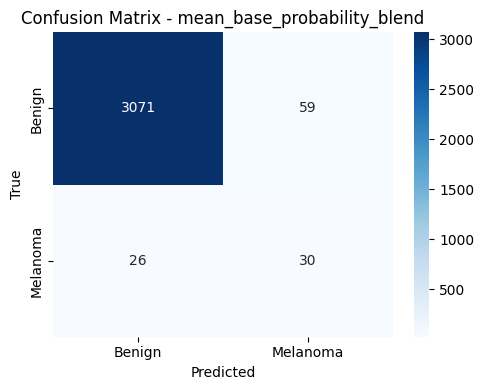

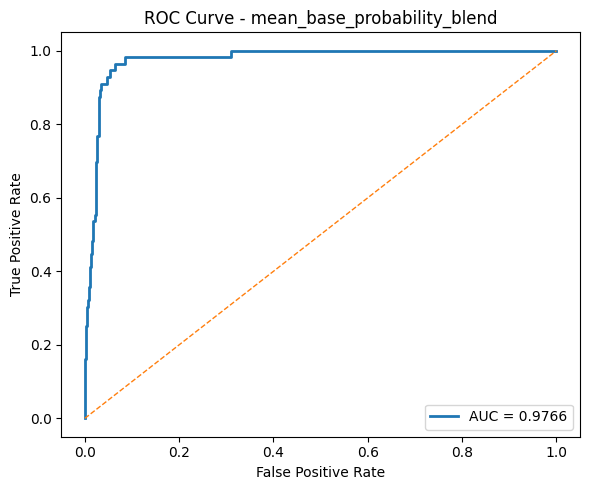

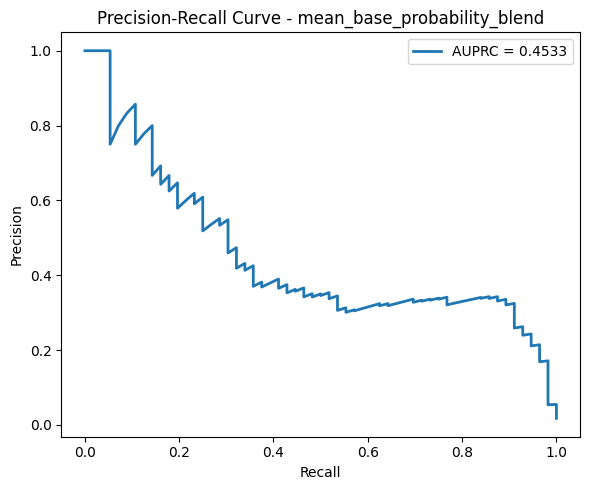

threshold       0.431263
precision       0.340278
recall          0.875000
f1              0.490000
tp             49.000000
fp             95.000000
tn           3035.000000
fn              7.000000
Name: 429, dtype: float64
mean_base_probability_blend_best_threshold AUC:   0.97664
mean_base_probability_blend_best_threshold AUPRC: 0.45333
mean_base_probability_blend_best_threshold Acc:   0.96798
mean_base_probability_blend_best_threshold F1:    0.49000
              precision    recall  f1-score   support

      Benign       1.00      0.97      0.98      3130
    Melanoma       0.34      0.88      0.49        56

    accuracy                           0.97      3186
   macro avg       0.67      0.92      0.74      3186
weighted avg       0.99      0.97      0.97      3186



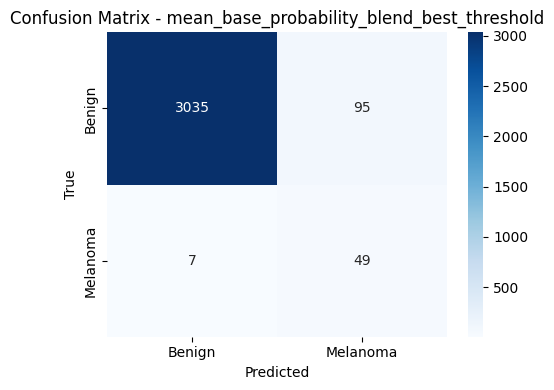

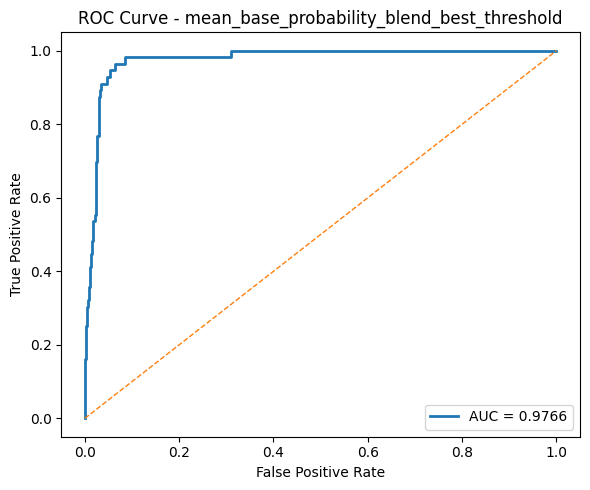

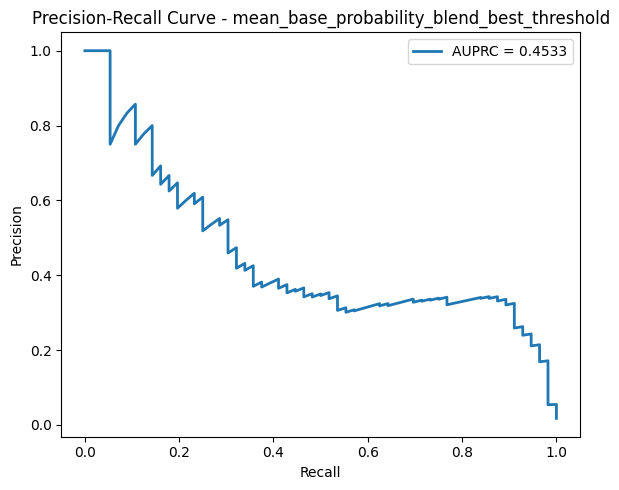

In [ ]:
# Run mean base blend
# force_features=False reuses existing feature caches
def run_mean_base_blend(force_features=False):
    seed_everything(SEED)

    train_paths, test_paths = run_prediction_extraction(force=force_features)
    base_probs_train, meta_train = merge_probability_caches(train_paths, split="train")
    base_probs_test, meta_test = merge_probability_caches(test_paths, split="test")

    train_blend = base_probs_train.mean(axis=1)
    test_blend = base_probs_test.mean(axis=1)

    submission = save_submission(meta_test, test_blend, name="submission_base_mean_blend.csv")

    val_mask = split_blend_validation(meta_train)
    val_meta = meta_train[val_mask].reset_index(drop=True)
    val_probs = train_blend[val_mask]
    y_val = val_meta["target"].values.astype(int)

    metrics_05 = evaluate_predictions(y_val, val_probs, name="mean_base_probability_blend", threshold=0.5)

    valid_pred = val_meta[["image_name", "target", "patient_id"]].copy()
    valid_pred["pred"] = val_probs
    valid_pred.to_csv(OUTPUT_DIR / "valid_predictions_mean_base_blend.csv", index=False)

    best_row, threshold_df = find_best_threshold(y_val, val_probs)
    print(best_row)
    threshold_df.to_csv(OUTPUT_DIR / "threshold_sweep_mean_base_blend.csv", index=False)

    metrics_best = evaluate_predictions(
        y_val,
        val_probs,
        name="mean_base_probability_blend_best_threshold",
        threshold=float(best_row["threshold"]),
    )

    pd.DataFrame([metrics_05, metrics_best]).to_csv(OUTPUT_DIR / "mean_blend_validation_metrics.csv", index=False)
    return submission, valid_pred, metrics_05, metrics_best, best_row


# Note that there may be training leakage
# Models from multiple people means that they might've trained on some of our val data used here
# Keep an eye out and be sceptical of high results, verify by submitting to Kaggle
submission, valid_pred_df, metrics_05, metrics_best, best_threshold = run_mean_base_blend(force_features=False)
